In [1]:
from deap import creator, base, tools, algorithms
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from datetime import datetime, timedelta
import math

random.seed(42)
np.random.seed(42)

# Загрузка и предобработка данных

In [2]:
df = pd.read_csv('D:\Python\РЗС\data\Automated_RSZ_distribution_enc.csv', sep=';')
df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])

C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\1186438947.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\Python\РЗС\data\Automated_RSZ_distribution_enc.csv', sep=';')


In [3]:
drop_list = df[(df['Инспектор, сменивший статус'].isna()) & (df['Статус РСЗ'] != 'Новое')]['№ схемы/риска'].unique()
df = df.drop(index=df[df['№ схемы/риска'].isin(drop_list)].index)
df.loc[df['Код НО инспектора, сменившего стат']=='000n', 'Код НО инспектора, сменившего стат'] = 0
df.drop_duplicates(inplace=True)
df['Дата выявления'] = pd.to_datetime(df['Дата выявления'], format='%Y-%m-%d %H:%M:%S')
df['Дата изменения статуса РСЗ'] = pd.to_datetime(df['Дата изменения статуса РСЗ'], format='%Y-%m-%d %H:%M:%S')
df['Код НО инспектора, сменившего стат'] = df['Код НО инспектора, сменившего стат'].astype(int)
df['Тип'] = df['Тип'].replace(
    to_replace={
        'Риск_долго': 'RISK_LONG',
        'Риск_быстро': 'RISK_SHORT',
        'Схема': 'SCHEMA', 
        'Задание': 'Task'
    },
    regex=True)

In [4]:
print("Общая информация о данных:")
print(f'Общее количество записей: {df.__len__()}')
print(f'Столбцы: {df.columns.to_list()}')

# Анализ статусов
print("\nРаспределение по статусам:")
print(df['Статус РСЗ'].value_counts())

# Анализ типов задач
print("\nРаспределение по типам:")
print(df['Тип'].value_counts())

Общая информация о данных:
Общее количество записей: 1373796
Столбцы: ['№ схемы/риска', 'Тип', 'Дата выявления', 'Статус РСЗ', 'Дата изменения статуса РСЗ', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'КПП', 'Наименование НП', 'Рег. номер декларации', 'Код периода', 'Период', 'Год декларации', 'Номер корректировки', 'Дата подачи декларации', 'Вид налога', 'Тип декларации', 'Дата обновления', 'Дата аннулирования НД', 'Дата окончания КНП']

Распределение по статусам:
Статус РСЗ
В работе                                                 563008
Новое                                                    331589
Нарушение подтверждено. Устранено уточнением сведений    161373
Нарушение не подтверждено                                128759
Нарушение подтверждено. Доказано                          62001
Установлены отрицательные изменения                       59883
Нарушение подтверждено. Не доказано                   

In [5]:
df[df['ИНН НП'] == '972-qyi-xxuq-qkjkk'][['№ схемы/риска', 'Тип', 'Дата выявления', 'Статус РСЗ', 'Дата изменения статуса РСЗ', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'Вид налога', 'Тип декларации', 'Рег. номер декларации', 'КПП']]

,№ схемы/риска,Тип,Дата выявления,Статус РСЗ,Дата изменения статуса РСЗ,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат","Потенциальный ущерб, руб",Номер проверки,ИНН НП,Вид налога,Тип декларации,Рег. номер декларации,КПП
1217277,8650312,SCHEMA,2024-05-18 12:40:37,Новое,2024-05-18 15:40:37,NaN,0,1339913.0,1-3456-25042024-2,972-qyi-xxuq-qkjkk,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,26227993-lbzs-uokg-ougj,5104-mdh-swzl-cykwr
522444,8650312,SCHEMA,2024-05-18 12:40:37,В работе,2024-05-20 10:30:20,75465-cjor-yeiznu-skqdclwc,3456,1339913.0,1-3456-25042024-2,972-qyi-xxuq-qkjkk,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,26227993-lbzs-uokg-ougj,5104-mdh-swzl-cykwr
537177,8650312,SCHEMA,2024-05-18 12:40:37,Нарушение подтверждено. Устранено уточнением с...,2024-08-26 09:19:09,75465-cjor-yeiznu-skqdclwc,3456,1339913.0,1-3456-25042024-2,972-qyi-xxuq-qkjkk,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,26227993-lbzs-uokg-ougj,5104-mdh-swzl-cykwr
1279554,9314112,RISK_LONG,2024-05-31 15:32:56,Новое,2024-05-31 18:32:56,NaN,0,3239139.6,1-3456-06052024-1,972-qyi-xxuq-qkjkk,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,60064354-nlhx-qxyf-iljs,5104-mdh-swzl-cykwr
717170,9314112,RISK_LONG,2024-05-31 15:32:56,В работе,2024-06-04 08:36:24,89953-gjvp-qtnagy-ixxbqztq,3456,3239139.6,1-3456-06052024-1,972-qyi-xxuq-qkjkk,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,60064354-nlhx-qxyf-iljs,5104-mdh-swzl-cykwr
729658,9314112,RISK_LONG,2024-05-31 15:32:56,Нарушение подтверждено. Устранено уточнением с...,2024-09-22 06:09:32,89953-gjvp-qtnagy-ixxbqztq,3456,3239139.6,1-3456-06052024-1,972-qyi-xxuq-qkjkk,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,60064354-nlhx-qxyf-iljs,5104-mdh-swzl-cykwr
1051836,9320908,RISK_SHORT,2024-06-01 19:54:22,Новое,2024-06-01 22:54:22,NaN,0,5876216.0,1-3453-14052024-1,972-qyi-xxuq-qkjkk,налогу на имущество организаций,Налоговая декларация по налогу на имущество ор...,77162645-tzqx-tygn-lawp,5104-mdh-swzl-cykwr
61494,9320908,RISK_SHORT,2024-06-01 19:54:22,В работе,2024-06-04 08:55:14,59845-cjjw-wtqapu-eobngowp,3453,5876216.0,1-3453-14052024-1,972-qyi-xxuq-qkjkk,налогу на имущество организаций,Налоговая декларация по налогу на имущество ор...,77162645-tzqx-tygn-lawp,5104-mdh-swzl-cykwr
2707,9320908,RISK_SHORT,2024-06-01 19:54:22,Установлены отрицательные изменения,2024-06-15 04:31:36,59845-cjjw-wtqapu-eobngowp,3453,5876216.0,1-3453-14052024-1,972-qyi-xxuq-qkjkk,налогу на имущество организаций,Налоговая декларация по налогу на имущество ор...,77162645-tzqx-tygn-lawp,5104-mdh-swzl-cykwr
1279712,9320909,RISK_SHORT,2024-06-01 19:54:22,Новое,2024-06-01 22:54:22,NaN,0,348776.0,1-3456-14052024-1,972-qyi-xxuq-qkjkk,налогу на имущество организаций,Налоговая декларация по налогу на имущество ор...,24281670-hygz-dpfx-tsus,5104-mdh-swzl-cykwr


In [6]:
df[df['№ схемы/риска'] == 6650851]

,№ схемы/риска,Тип,Дата выявления,Статус РСЗ,Дата изменения статуса РСЗ,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат","Потенциальный ущерб, руб",Номер проверки,ИНН НП,...,Код периода,Период,Год декларации,Номер корректировки,Дата подачи декларации,Вид налога,Тип декларации,Дата обновления,Дата аннулирования НД,Дата окончания КНП
1290112,6650851,RISK_SHORT,2023-12-15 22:30:23,Новое,2023-12-16 01:30:23,NaN,0,653646.2,1-5027-11122023-1,156-asp-eqja-wyskj,...,40,шесть месяцев,2023,1,2023-12-12 00:00:00,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,2023-12-16 01:30:23,NaN,2024-03-11 00:00:00
773223,6650851,RISK_SHORT,2023-12-15 22:30:23,В работе,2023-12-18 12:28:50,99276-qclx-mwjfkv-edzcizwb,5027,653646.2,1-5027-11122023-1,156-asp-eqja-wyskj,...,40,шесть месяцев,2023,1,2023-12-12 00:00:00,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,2023-12-18 12:28:50,NaN,2024-03-11 00:00:00
777310,6650851,RISK_SHORT,2023-12-15 22:30:23,Установлены отрицательные изменения,2023-12-29 01:30:15,33778-wooo-exojim-inbtqark,5027,653646.2,1-5027-11122023-1,156-asp-eqja-wyskj,...,40,шесть месяцев,2023,1,2023-12-12 00:00:00,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,2023-12-29 01:30:15,NaN,2024-03-11 00:00:00
773269,6650851,RISK_SHORT,2023-12-15 22:30:23,Установлены отрицательные изменения,2024-01-10 09:59:27,33778-wooo-exojim-inbtqark,5027,653646.2,1-5027-11122023-1,156-asp-eqja-wyskj,...,40,шесть месяцев,2023,1,2023-12-12 00:00:00,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,2024-01-10 09:59:27,NaN,2024-03-11 00:00:00


In [7]:
df[(df['Дата изменения статуса РСЗ'] < datetime(2024, 1, 1)) & (~df['Статус РСЗ'].isin(['В работе', 'Новое']))]

,№ схемы/риска,Тип,Дата выявления,Статус РСЗ,Дата изменения статуса РСЗ,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат","Потенциальный ущерб, руб",Номер проверки,ИНН НП,...,Код периода,Период,Год декларации,Номер корректировки,Дата подачи декларации,Вид налога,Тип декларации,Дата обновления,Дата аннулирования НД,Дата окончания КНП
148258,4951607,RISK_LONG,2021-11-12 21:30:57,Нарушение не подтверждено,2022-01-25 08:59:56,40069-vrug-wzbudo-ufyaxasv,6316,1.625332e+05,1-6316-25102021-6,526-nfc-mawy-ugjmj,...,23,III квартал,2021,0,2021-10-25 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2022-01-25 08:59:56,NaN,2022-01-25 00:00:00
800143,4952608,RISK_SHORT,2021-11-12 21:31:43,Нарушение не подтверждено,2022-01-24 08:15:40,80972-fkff-abpanr-jrhrknmk,5100,7.333550e+04,1-5190-22102021-3,888-loq-kczq-swdov,...,23,III квартал,2021,0,2021-10-22 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2022-01-24 08:15:40,NaN,2021-12-22 00:00:00
278692,4952818,RISK_SHORT,2021-11-12 21:31:23,Нарушение не подтверждено,2022-01-24 08:16:48,80972-fkff-abpanr-jrhrknmk,5100,2.495850e+03,1-5190-21102021-1,274-vbf-cwjr-inhib,...,23,III квартал,2021,0,2021-10-21 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2022-01-24 08:16:48,NaN,2021-12-21 00:00:00
278172,4959974,RISK_SHORT,2022-01-10 02:59:56,Ожидает обработки,2022-01-13 16:08:15,93612-obtd-ykldbs-elteahep,7460,1.158792e+07,1-7460-25102021-1,297-nuh-ledy-uxzov,...,23,III квартал,2021,0,2021-10-25 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2022-01-13 16:08:15,NaN,2021-12-27 00:00:00
148273,4959985,RISK_SHORT,2022-01-10 02:59:57,Ожидает обработки,2022-02-08 14:24:38,43793-vsli-onrqan-hfvnsqeh,4000,1.432427e+04,1-4028-25102021-1,590-tei-mosb-swscb,...,23,III квартал,2021,0,2021-10-25 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2022-02-08 14:24:38,NaN,2021-12-27 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777310,6650851,RISK_SHORT,2023-12-15 22:30:23,Установлены отрицательные изменения,2023-12-29 01:30:15,33778-wooo-exojim-inbtqark,5027,6.536462e+05,1-5027-11122023-1,156-asp-eqja-wyskj,...,40,шесть месяцев,2023,1,2023-12-12 00:00:00,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,2023-12-29 01:30:15,NaN,2024-03-11 00:00:00
345194,6653086,RISK_LONG,2023-12-13 16:00:18,Нарушение не подтверждено,2023-12-14 11:47:05,87828-fkij-xjojex-otioksyf,6800,2.292026e+06,1-6800-29112023-1,767-fjs-fuuu-hofnz,...,34,год,2022,2,2023-11-29 00:00:00,УСН,"Налоговая декларация по налогу, уплачиваемому ...",2023-12-14 11:47:05,NaN,2024-03-25 00:00:00
149244,6667333,SCHEMA,2023-12-14 10:00:13,Нарушение не подтверждено,2023-12-21 13:33:59,58896-zhwg-xyipzc-rwizrnkq,9111,9.004734e+05,1-9111-07082023-1,361-ppu-ekoh-vzylv,...,22,II квартал,2023,6,2023-08-07 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2023-12-21 13:33:59,NaN,2024-05-27 00:00:00
345180,6667337,SCHEMA,2023-12-14 10:00:16,Нарушение не подтверждено,2023-12-21 13:33:59,58896-zhwg-xyipzc-rwizrnkq,9111,9.004734e+05,1-9111-07082023-1,361-ppu-ekoh-vzylv,...,22,II квартал,2023,6,2023-08-07 00:00:00,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,2023-12-21 13:33:59,NaN,2024-05-27 00:00:00


In [8]:
df[(df['Дата изменения статуса РСЗ'] < datetime(2024, 1, 1)) & (~df['Статус РСЗ'].isin(['В работе', 'Новое']))]['№ схемы/риска'].nunique()

435

In [9]:
df['Рег. номер декларации'].value_counts()

Рег. номер декларации
78013429-hwmj-awxz-egok    63147
33164445-moqp-jcmw-gykm    14190
86245631-jfoy-zgsz-okfi     8631
91979762-yqpw-ywjk-nzet     6468
46475045-wgty-xbaf-mlln     6320
                           ...  
14557752-cxfi-nrsc-fckb        1
66798912-usni-xsdj-hnne        1
14354819-yviv-hjqz-viwg        1
51904364-tvyz-esfg-ntem        1
51577995-yobh-fhon-imgy        1
Name: count, Length: 267243, dtype: int64

In [10]:
# Анализ инспекторов
print('Распределение по инспекторам')
print(df['Инспектор, сменивший статус'].value_counts())

Распределение по инспекторам
Инспектор, сменивший статус
30250-fzog-omkeqi-eoszfzxy    42098
75845-oadk-xuuthe-iorbemnl    13638
56214-vxdc-qmbdkl-lgvrvnzm     7195
99404-xycu-argxqc-vbquafed     5432
33199-xfft-ohhuuq-yhngrscb     5104
                              ...  
53080-pmcv-dkcfvg-fnapfwfa        1
20297-thuo-ejvlfl-ylwhhrlj        1
79662-kvdb-cccfbk-uhguuekp        1
71328-fgit-apqqzm-yvciojaw        1
82985-cqdf-pxgqoq-dmckiobz        1
Name: count, Length: 12631, dtype: int64


In [11]:
# анализ количества новых задач
# grouped_analiz_df = df.groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус']].last()
# grouped_analiz_df[grouped_analiz_df['Статус РСЗ'] == 'Новое']

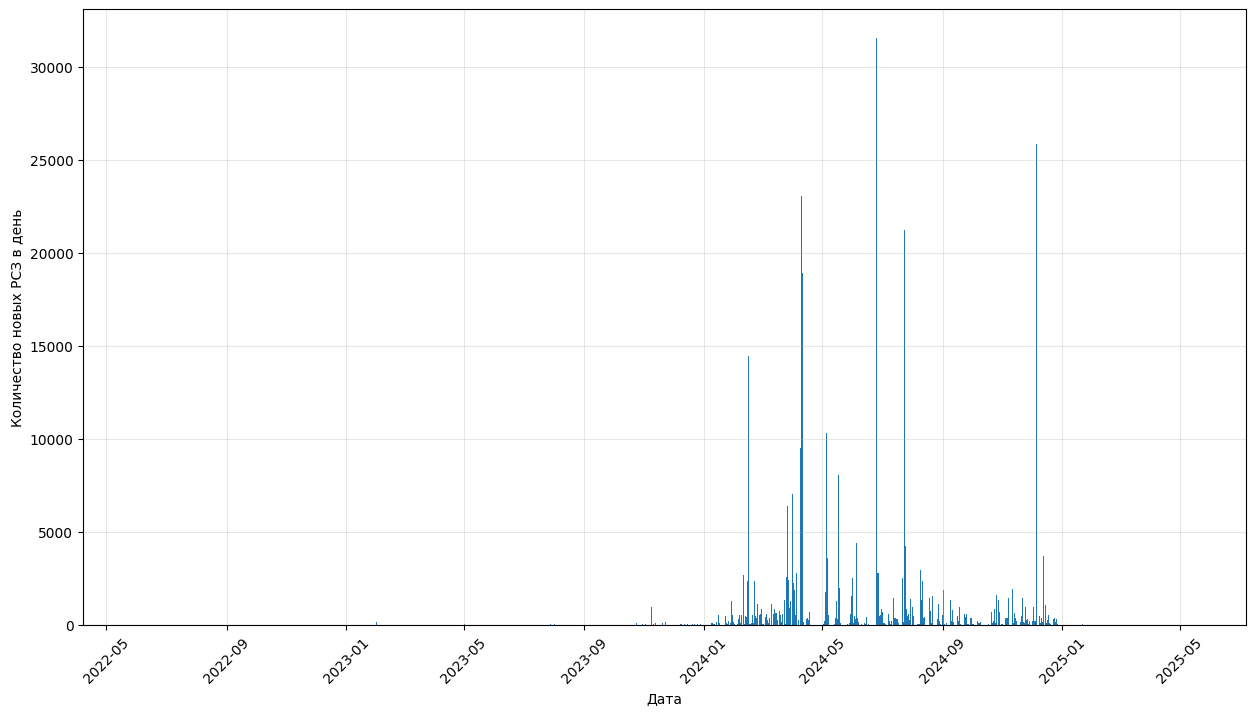

In [12]:
cloned_df = df.copy()
cloned_df = cloned_df[cloned_df['Статус РСЗ'] == 'Новое']
cloned_df['Дата'] = cloned_df['Дата изменения статуса РСЗ'].dt.date
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] > '2024-06-01 00:00:00']
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] < '2024-07-01 00:00:00']
bar_df = cloned_df.groupby('Дата')['Статус РСЗ'].count()
plt.figure(figsize=(15, 8))
plt.bar(x=bar_df.index, height=bar_df, width=1)
plt.xticks(rotation=45)
plt.ylabel('Количество новых РСЗ в день')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
# plt.ylim(0, 100)

In [13]:
cloned_df
daily_counts = cloned_df[['№ схемы/риска', 'Дата изменения статуса РСЗ']].set_index('Дата изменения статуса РСЗ').resample('D').size().reset_index(name='count')
daily_counts['year'] = daily_counts['Дата изменения статуса РСЗ'].dt.year
daily_counts

daily_counts.groupby('year').agg(
    total_tasks=('count', 'sum'),
    max_daily_tasks=('count', 'max'),
    avg_daily_tasks=('count', 'mean')
).reset_index()

,year,total_tasks,max_daily_tasks,avg_daily_tasks
0,2022,82,32,0.383178
1,2023,3479,965,9.531507
2,2024,327950,31512,896.038251
3,2025,78,37,0.582090


In [14]:
# аrtifacts_list =  [7811755,  9346950,  9430063,  9446746,  9448905,  9451172,  9951162,
#        10280672, 10297671, 10304978, 11646767, 13341131, 14949625, 15158496,
#        15179189, 15256689, 15357780]
# df[df['№ схемы/риска'] == 9451172]

## Распределение баллов по задачам и инспекторам в соответствии с автостатусами

In [15]:
copy_df = df.copy()

In [16]:
# 20% в новое
def get_new_type_data(day: str = '2024-06-27', df: pd.DataFrame = copy_df):
    # df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])
    day += ' 00:00:00'
    date_format = '%Y-%m-%d %H:%M:%S'
    day_str = datetime.strptime(day, date_format)
    day_before_str = day_str - timedelta(days=1)
    quartal_day_str = day_str - timedelta(days=90)
    
    day_df = df[df['Дата изменения статуса РСЗ'] <= day_str]    
    
    columns = ['Статус РСЗ', 'Тип', 'Дата изменения статуса РСЗ', 'Потенциальный ущерб, руб', 'ИНН НП', 'Вид налога', 'Тип декларации', 'Рег. номер декларации', 'КПП']

    cutten_day_df = day_df[day_df['Дата изменения статуса РСЗ'] > day_before_str]
    new_tasks_df = cutten_day_df[cutten_day_df['Статус РСЗ'] == 'Новое'].groupby('№ схемы/риска')[columns].last()
    
    inwork_tasks_df = df[df['Дата изменения статуса РСЗ'] <= day_before_str].groupby('№ схемы/риска')[columns + ['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат',]].last()
    new_tasks_df = pd.concat([new_tasks_df, inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'Новое']])
    new_tasks_df.drop(columns=['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат'], inplace=True)
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'Новое']
    finish_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'В работе']
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'В работе']
    
    # Динамическая обрезка по результативности
    finish_tasks_df = finish_tasks_df[finish_tasks_df['Дата изменения статуса РСЗ'] >= quartal_day_str]
    
    return new_tasks_df, inwork_tasks_df, finish_tasks_df

In [17]:
new_tasks_df, inwork_tasks_df, finish_tasks_df = get_new_type_data('2024-06-27')

In [18]:
# Автораздача РСЗ по ИНН
inn_df = inwork_tasks_df.groupby('ИНН НП')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last() #Большая заглушка не все работы с одним ИНН идут одному работнику. Даже ни в один ТНО порой. Пример ИНН: 972-qyi-xxuq-qkjkk
auto_dis = new_tasks_df.merge(inn_df, how='inner', left_on='ИНН НП', right_index=True)
auto_dis['Статус РСЗ'] = auto_dis['Статус РСЗ'].replace('Новое', 'В работе')
inwork_tasks_df = pd.concat([inwork_tasks_df, auto_dis])
new_tasks_df.drop(index=auto_dis.index, inplace=True)
auto_dis.head()

,Статус РСЗ,Тип,Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,Вид налога,Тип декларации,Рег. номер декларации,КПП,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат"
№ схемы/риска,,,,,,,,,,,
6750711,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,30572102-ytja-djxd-hqco,5961-wvy-tkzc-xjrxp,57803-sqnl-gwvmnj-uqvvyzki,7708
7696445,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,30572102-ytja-djxd-hqco,5961-wvy-tkzc-xjrxp,57803-sqnl-gwvmnj-uqvvyzki,7708
7807914,В работе,RISK_SHORT,2024-06-26 12:22:00,2240982.2,750-vdi-otro-pvugc,налогу на прибыль организаций,Налоговая декларация по налогу на прибыль орга...,40131860-uxxz-kprd-tcsc,6918-pjx-albl-ovxxt,51465-moum-qjwvyg-ccddrmiq,4300
8655780,В работе,RISK_SHORT,2024-06-26 22:39:18,1225448.0,901-rlu-yhcx-ejmrz,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,51591325-ldnh-xvqs-jpcb,1238-gwy-rdrn-ywxwu,81591-piom-czhlxo-aawpfqte,7100
9366155,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,30572102-ytja-djxd-hqco,5961-wvy-tkzc-xjrxp,57803-sqnl-gwvmnj-uqvvyzki,7708


In [19]:
print('Число новых РСЗ поступивших в этот день в налоговую:', len(new_tasks_df))

Число новых РСЗ поступивших в этот день в налоговую: 31563


In [20]:
Auto_Stats = pd.DataFrame({
 'Новое':                                                   [0, 0, 0, 0],
 'В работе':                                                [0, 0, 0, 0],
 'Нарушение подтверждено. Устранено уточнением сведений':   [100, 86, 46, 0],
 'Нарушение не подтверждено':                               [50, 43, 23 , 0],
 'Нарушение подтверждено. Доказано':                        [75, 65, 35, 0],
 'Установлены отрицательные изменения':                     [0, 0, 0, 0],
 'Нарушение подтверждено. Не доказано':                     [40, 34, 18, 0],
 'Не доказано':                                             [40, 34, 18, 0],
 'Декларация аннулирована':                                 [60, 52, 28, 0],
 'Разакцептование':                                         [0, 0, 0, 0],
 'Архив':                                                   [0, 0, 0, 0],
 'Ожидает обработки':                                       [0, 0, 0, 0],
 'Разакцептован':                                           [0, 0, 0, 0],
 'На проверке':                                             [0, 0, 0, 0],
 'Выполнено':                                               [0, 0, 0, 3], 
 'Не выполнено':                                            [0, 0, 0, 0],
}).transpose()
Auto_Stats.columns = ['SCHEMA', 'RISK_LONG', 'RISK_SHORT', 'TASK']

In [21]:
all_scores = [Auto_Stats.loc[stat, df.iloc[i, 1]] for i, stat in enumerate(finish_tasks_df['Статус РСЗ'])]
finish_tasks_df['Score'] = all_scores
finish_tasks_df.head()

,Статус РСЗ,Тип,Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,Вид налога,Тип декларации,Рег. номер декларации,КПП,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат",Score
№ схемы/риска,,,,,,,,,,,,
4950646,Архив,RISK_LONG,2024-06-19 04:23:42,1.015848e+04,931-jab-mmsl-gblig,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,69655237-ryiz-odfn-czbb,1970-euc-tcbh-aposy,65221-yoto-fpnfvk-ljuqhapf,7000,0
4950777,Нарушение подтверждено. Доказано,RISK_LONG,2024-04-17 08:06:41,2.590096e+05,378-uui-bxkr-yhlem,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,25532613-aztm-llqb-chel,9958-voe-mtba-hlkbr,20348-icof-oamlkh-idstpyvq,6316,65
4951607,Нарушение не подтверждено,RISK_LONG,2024-04-17 08:07:22,1.625332e+05,526-nfc-mawy-ugjmj,налогу на добавленную стоимость,Налоговая декларация по налогу на добавленную ...,54086603-xbiz-hvfz-mxqd,7543-iiz-ubwq-wjiem,48306-zpes-keykzc-tzlhtgvc,6316,43
4984198,Нарушение подтверждено. Устранено уточнением с...,RISK_SHORT,2024-06-07 09:59:08,2.223600e+04,712-rqj-hezy-tuhzz,налогу на имущество организаций,Налоговая декларация по налогу на имущество ор...,88089294-rtme-thok-udsc,1961-tvs-nqrg-xbznh,37371-nive-ivhykm-sfxluzbt,600,86
5249127,Нарушение не подтверждено,RISK_SHORT,2024-04-05 10:44:30,1.629243e+06,477-iko-qxdl-dxelg,УСН,"Налоговая декларация по налогу, уплачиваемому ...",30865271-whhm-qdrn-ormh,8926-ntr-ycpn-mlcer,96708-flnm-yxlgbl-wdwaomtu,2365,43


## Создание датасета о инструктарах

In [22]:
N_ended_works = finish_tasks_df.groupby('Инспектор, сменивший статус')['Score'].count()

inspectors_df = pd.DataFrame(copy_df.groupby('Инспектор, сменивший статус')['Код НО инспектора, сменившего стат'].last())
inspectors_efficiency = finish_tasks_df[finish_tasks_df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].sum()/N_ended_works/100
inspectors_df = inspectors_df.merge(inspectors_efficiency, how='left', left_index=True, right_index=True)
inspectors_df.fillna(0, inplace=True)
inspectors_df['Experience'] = [np.random.random()/2 for i in range(len(inspectors_df))]
inspectors_df['Qualification'] = inspectors_df['Score'] + inspectors_df['Experience']

## Подготовка нераспределённых РСЗ

In [23]:
insp_df = copy_df.groupby('№ схемы/риска')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last()
new_tasks_df = new_tasks_df.merge(insp_df, how='left', left_index=True, right_index=True)

In [24]:
distribution_new_tasks = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
distribution_new_tasks.update((k, new_tasks_df['Тип'].value_counts().to_dict()[k]) for k in set(distribution_new_tasks) & set(new_tasks_df['Тип'].value_counts().to_dict()))
distribution_new_tasks

{'RISK_SHORT': 31467, 'SCHEMA': 84, 'RISK_LONG': 12, 'TASK': 1}

In [25]:
# Функция для разбиванию инспекторов и РСЗ по НО
def filter_by_no(no_code:int, dataframe:pd.DataFrame = new_tasks_df):
    
    no_inspectors_df = inspectors_df[inspectors_df['Код НО инспектора, сменившего стат'] == no_code]
    no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
    
    mask = no_inspectors_df['Qualification'] >= 0.71 * no_inspectors_df['Qualification'].max()

    # Используем np.where для каждого столбца
    no_inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
    no_inspectors_df['p_RISK_LONG'] = np.where(mask, 0.5, 0)
    no_inspectors_df['p_RISK_SHORT'] = np.where(mask, 0, 0.5)
    no_inspectors_df['p_TASK'] = np.where(mask, 0, 0.5)
    
    # Заспределяем новые задачи по НО    
    # dataframe = dataframe.merge(inspectors_df[['Код НО инспектора, сменившего стат']], how='left', left_on='Инспектор, сменивший статус', right_index=True)
    dataframe['Код НО инспектора, сменившего стат'] = dataframe['Код НО инспектора, сменившего стат'].fillna(0).astype(int)
    no_df = dataframe[dataframe['Код НО инспектора, сменившего стат'] == no_code]
    
    return no_inspectors_df, no_df,

In [26]:
def start_data_prep(inspectors_df: pd.DataFrame, df: pd.DataFrame, in_work: pd.DataFrame = None):
    # Расчёт вероятности передачи определённого типа задачи сотруднику --> np.array(сотрудники, типы задач)
    task_prob = [inspectors_df['p_SCHEMA'].to_list(), inspectors_df['p_RISK_LONG'].to_list(), inspectors_df['p_RISK_SHORT'].to_list(), inspectors_df['p_TASK'].to_list(),]
    task_prob = np.array([*zip(*task_prob)])
    
    # Определения числа распределяемых задач и числа сотрудников --> int, int
    N, M = df.__len__(), inspectors_df.__len__()
    
    # Создание массива хранящего в себе тип задачи по порядку --> np.array(число распределяемых задач)
    if in_work is not None:
        concate_df = pd.concat([df, in_work])
    else:
        concate_df = df
    task_cat = concate_df['Тип'].to_numpy()
    
    # Создание словаря хранящего количество распределяемых задач данного типа --> dict()
    den_TNO = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
    den_TNO.update((k, concate_df['Тип'].value_counts().to_dict()[k]) for k in set(den_TNO) & set(concate_df['Тип'].value_counts().to_dict()))
    
    return task_prob, N, M, task_cat, den_TNO

### Функция расчёта нагрузки и эффективности

In [27]:
def evaluation(individual: list, den_TNO: dict, task_cat: np.array, task_prob: np.array, M: int, results: bool = False, current_individ: list = []):
    full_ind = individual + current_individ
    K1, K2, K3, K4 = 100, 80, 46, 3
    K_SUM = K1 + K2 + K3 + K4
    cnt = {cat: np.zeros(M, dtype=int) for cat in den_TNO} 
    for j, emp_idx in enumerate(full_ind):
        cnt[task_cat[j]][emp_idx] += 1
    
    nu = (
        cnt["SCHEMA"]     / den_TNO["SCHEMA"]     * K1 +
        cnt["RISK_LONG"]  / den_TNO["RISK_LONG"]  * K2 +
        cnt["RISK_SHORT"] / den_TNO["RISK_SHORT"] * K3 +
        cnt["TASK"]       / den_TNO["TASK"]       * K4
    ) / K_SUM * 100
    
    
    efficiency = (
        cnt["SCHEMA"]     * task_prob[:, 0]   / den_TNO["SCHEMA"]     +
        cnt["RISK_LONG"]  * task_prob[:, 1]   / den_TNO["RISK_LONG"]  +
        cnt["RISK_SHORT"] * task_prob[:, 2]   / den_TNO["RISK_SHORT"] +
        cnt["TASK"]       * task_prob[:, 3]   / den_TNO["TASK"]       
    ).sum() *100
    
    max_load = nu.max() - nu.min()
    std_load = nu.std()
    
    if not results:
        return max_load, efficiency, std_load,
    return nu, efficiency, 

### Функция оптимизации

In [28]:
def Multi_optimization(no_code: int, population_size: int = 200, epoches: int = 100, p_crossing: float = 0.5, p_mutation: float = 0.25):
    
    random.seed(42)
    np.random.seed(42)
    
    no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)

    in_work_indiv = in_work_no_df.merge(no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
    in_work_indiv = in_work_indiv['Inspector index'].to_list()
        
    no_inspectors_df, no_df = filter_by_no(no_code)
    task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
        
    func = partial(evaluation, den_TNO=den_TNO, task_cat=task_cat, task_prob=task_prob, M=M, current_individ=in_work_indiv)
    
    creator.create('FintesMulti', base.Fitness, weights=(-1, 1, -1)) # load ↓, efficiency ↑
    creator.create('Individual', list, fitness=creator.FintesMulti)
    
    toolbox = base.Toolbox()
    fit1_stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
    fit2_stats = tools.Statistics(key=lambda ind: ind.fitness.values[1])
    fit3_stats = tools.Statistics(key=lambda ind: ind.fitness.values[2])

    mstats = tools.MultiStatistics(fit1=fit1_stats, fit2=fit2_stats, fit3=fit3_stats)
    mstats.register("min", np.min)
    mstats.register("avg", np.mean)
    mstats.register("max", np.max)

    toolbox.register('attr_int', np.random.randint, 0, M)
    toolbox.register('individual', tools.initRepeat, creator.Individual, 
                    toolbox.attr_int, N)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", func)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register('mutate', tools.mutUniformInt,  low=0, up=M-1, indpb=0.1)
    toolbox.register('select', tools.selNSGA2)
    
    hall_of_fame = tools.HallOfFame(np.inf)
    population = toolbox.population(population_size)
    pop, logbook = algorithms.eaMuPlusLambda(population, 
                                    toolbox, 
                                    mu=population_size//2,
                                    lambda_=population_size//2,
                                    cxpb=p_crossing, mutpb=p_mutation, ngen=epoches, 
                                    halloffame=hall_of_fame,
                                    stats=mstats, verbose=True)
    
    pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    uniq_pareto = []
    for ind in pareto:
        if ind not in uniq_pareto:
            uniq_pareto.append(ind)
            
    print("Len of Pareto set:", len(uniq_pareto))
    return hall_of_fame, uniq_pareto
    

## Оптимизация по выбраному НО

In [29]:
df['Код НО инспектора, сменившего стат'].nunique()

437

In [30]:
# no_code = new_tasks_df.groupby('Код НО инспектора, сменившего стат')['Статус РСЗ'].count().sort_values(ascending=False).index[0] #new_tasks_df['Код НО инспектора, сменившего стат'].unique()[0]
# no_code = new_tasks_df[new_tasks_df['Тип']=='SCHEMA'].groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()
# no_code = inspectors_df.groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()
no_code = 3700
no_code

3700

In [31]:
no_inspectors_df, no_df = filter_by_no(no_code)
no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)
task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
hall_of_fame, uniq_pareto = Multi_optimization(no_code)

C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

   	      	                 fit1                 	                 fit2                 	                 fit3                 
   	      	--------------------------------------	--------------------------------------	--------------------------------------
gen	nevals	avg    	gen	max    	min    	nevals	avg    	gen	max    	min    	nevals	avg   	gen	max    	min    	nevals
0  	200   	10.6121	0  	10.7861	10.4498	200   	54.0986	0  	55.4338	52.4658	200   	1.9952	0  	2.02272	1.97074	200   
1  	74    	10.5586	1  	10.7861	10.4498	74    	54.4277	1  	55.4338	53.3029	74    	1.99019	1  	2.00612	1.97074	74    
2  	77    	10.5424	2  	10.7249	10.4498	77    	54.6522	2  	55.586 	53.3029	77    	1.98902	2  	2.00681	1.97074	77    
3  	75    	10.5177	3  	10.6944	10.4498	75    	54.7184	3  	56.1187	53.379 	75    	1.98692	3  	2.00681	1.97074	75    
4  	72    	10.5066	4  	10.6944	10.4192	72    	54.8295	4  	56.1187	53.4551	72    	1.98549	4  	2.00326	1.97038	72    
5  	72    	10.506 	5  	10.6944	10.4192	72    	54.9

### Анализ существуюшей нагрузки и её эффективности

C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
C:\Users\zincc\AppData\Local\Temp\ipykernel_14896\3179637002.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

10.480349344978166


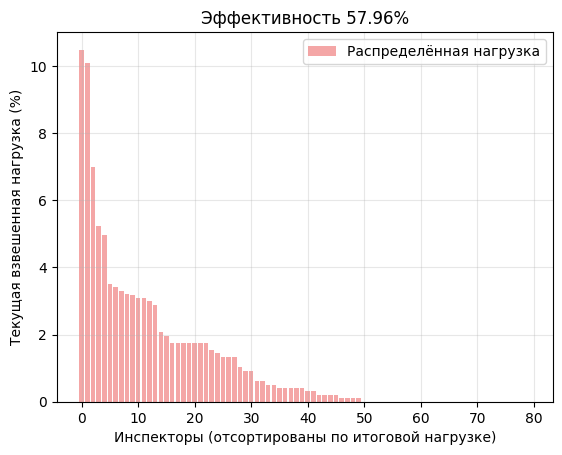

In [32]:
current_no_inspectors_df, current_no_df = filter_by_no(no_code, inwork_tasks_df)
current_task_prob, current_N, current_M, current_task_cat, current_den_TNO = start_data_prep(current_no_inspectors_df, current_no_df)
current_no_df = current_no_df.merge(current_no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
current_individ = current_no_df['Inspector index'].to_list()

current_load, current_eff = evaluation(current_individ, den_TNO=current_den_TNO, task_cat=current_task_cat, M=current_M, task_prob=current_task_prob, results=True)
sorted_current_load = np.sort(current_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_current_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')
print(max(current_load))

10.480349344978166


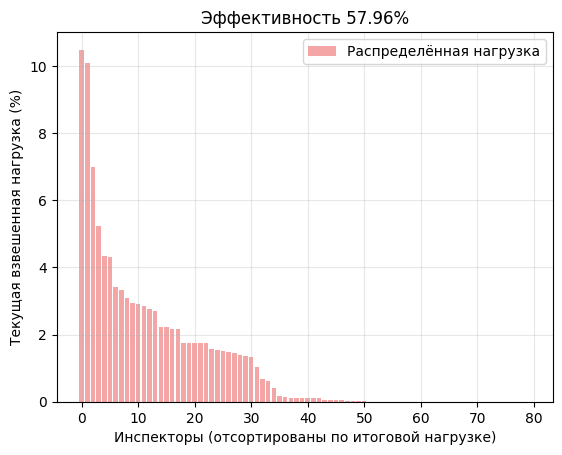

In [33]:
future_individ = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
future_individ = future_individ.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='Инспектор, сменивший статус', right_on='Инспектор, сменивший статус')
future_individ = future_individ['Inspector index'].to_list()
future_load, future_eff = evaluation(future_individ, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
sorted_future_load = np.sort(future_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_future_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')
print(max(current_load))

### Анализ результатов оптимизации распределения новых задач

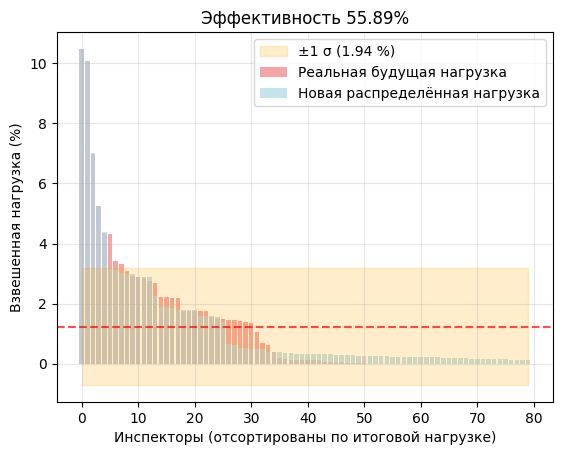

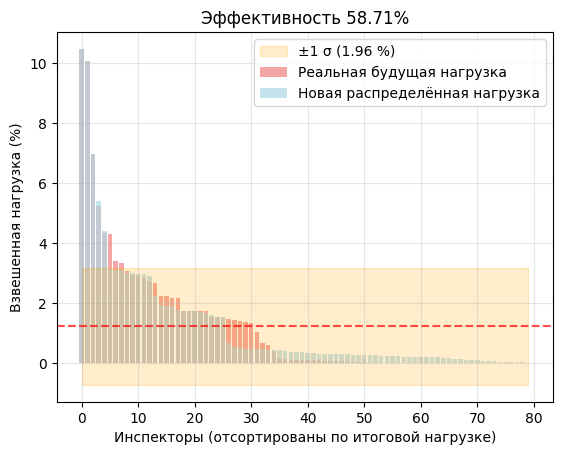

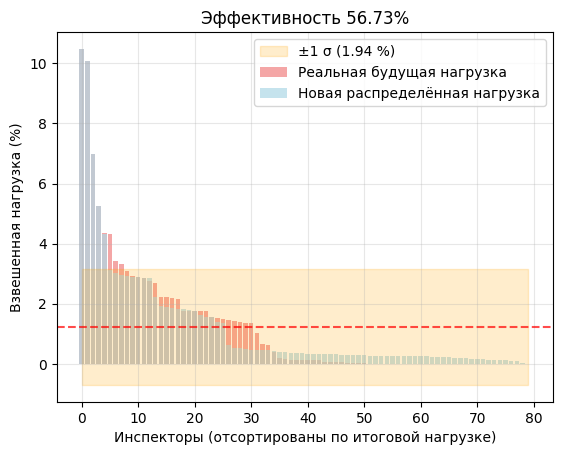

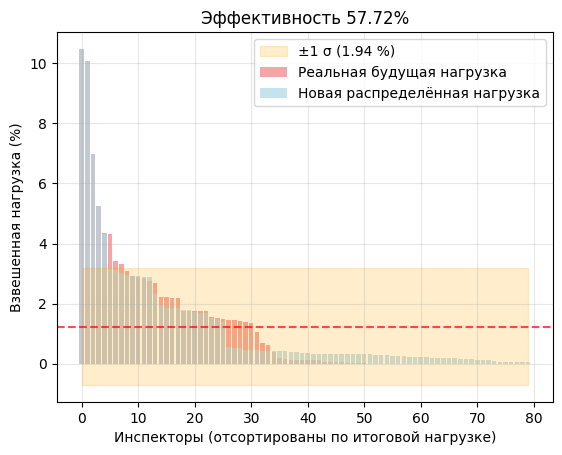

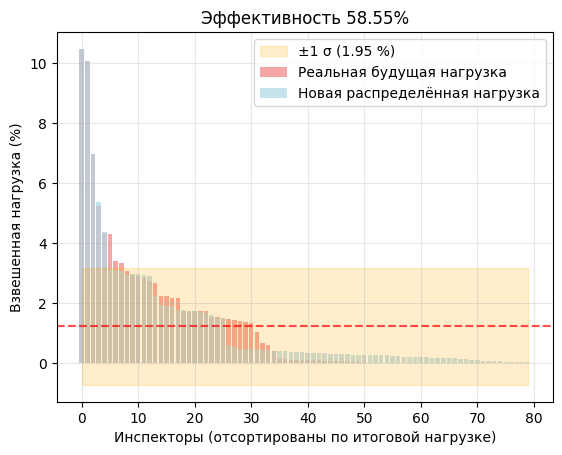

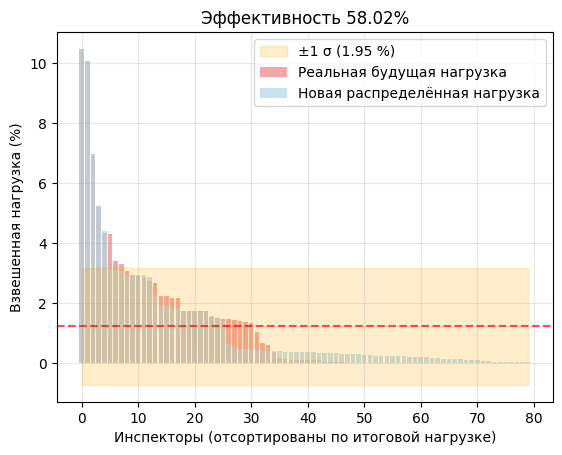

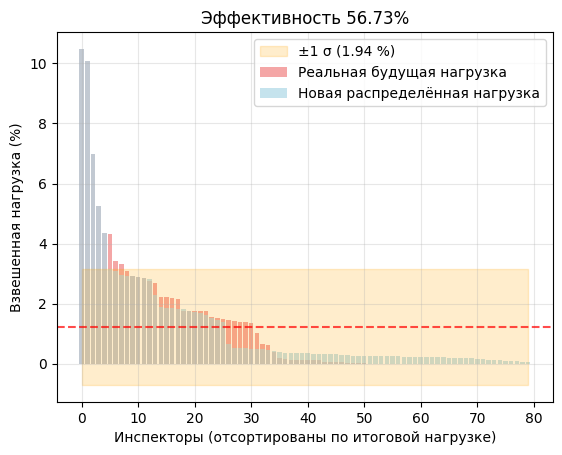

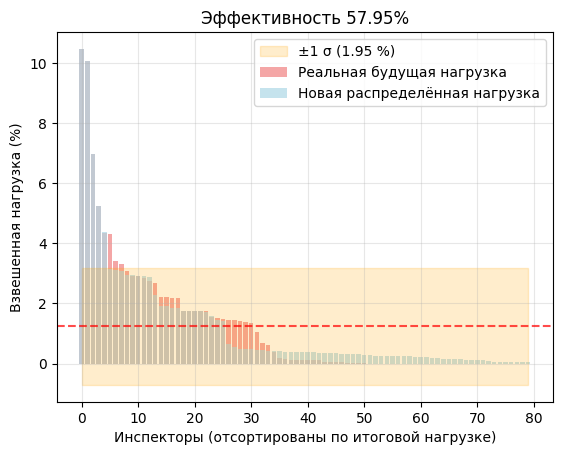

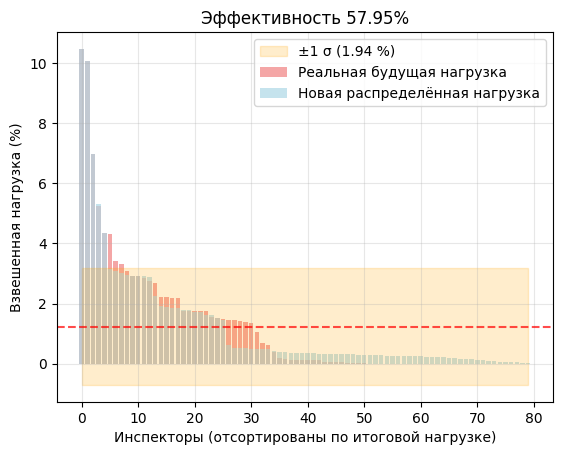

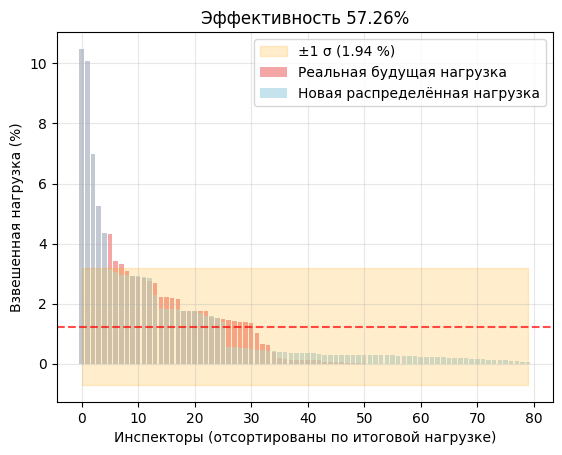

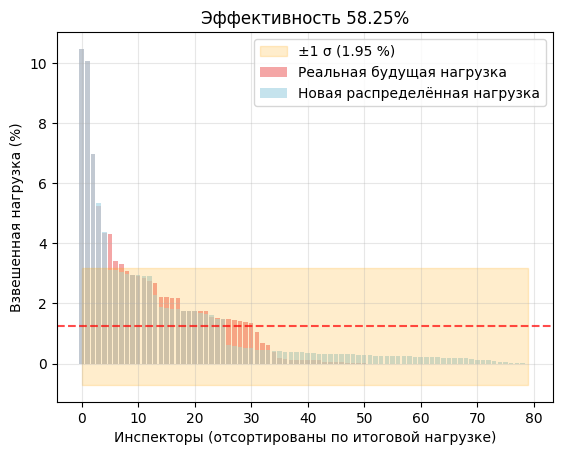

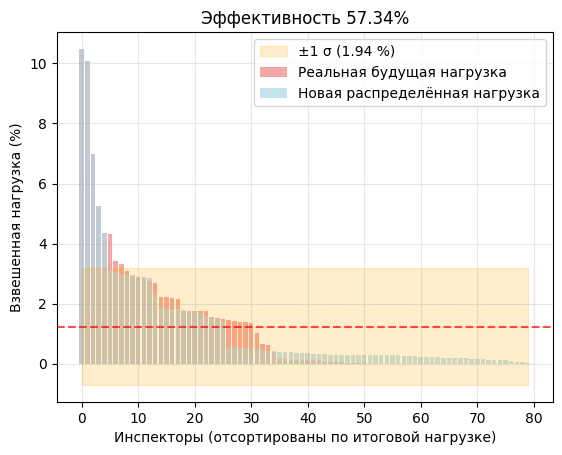

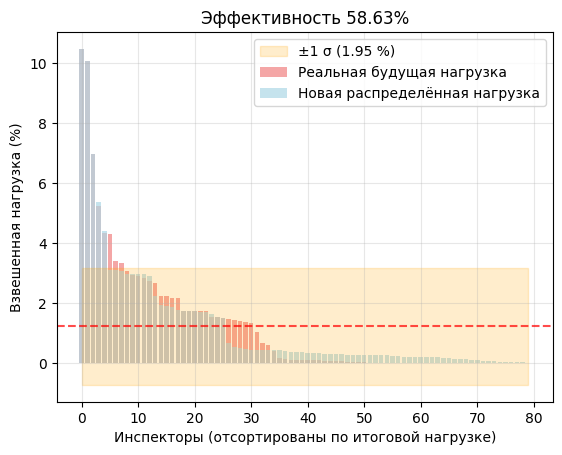

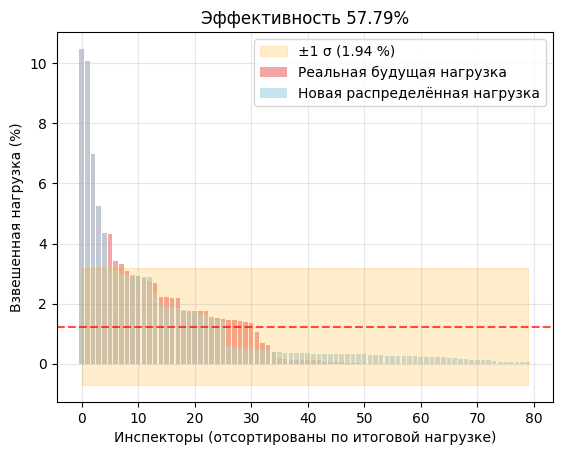

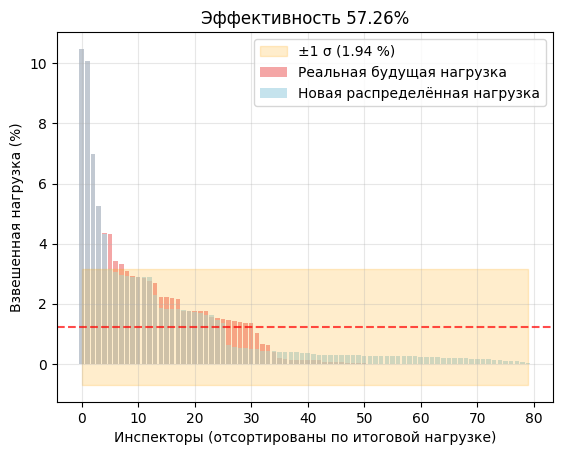

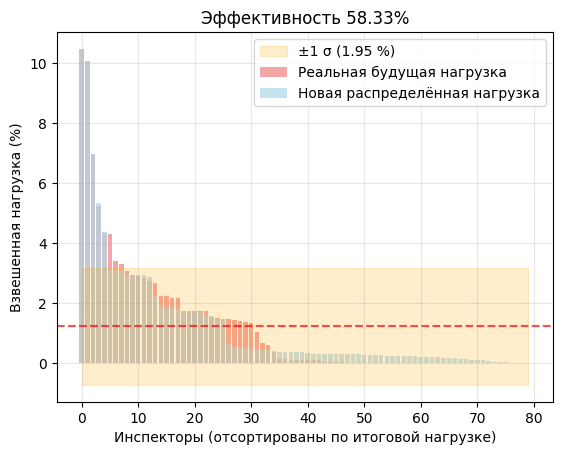

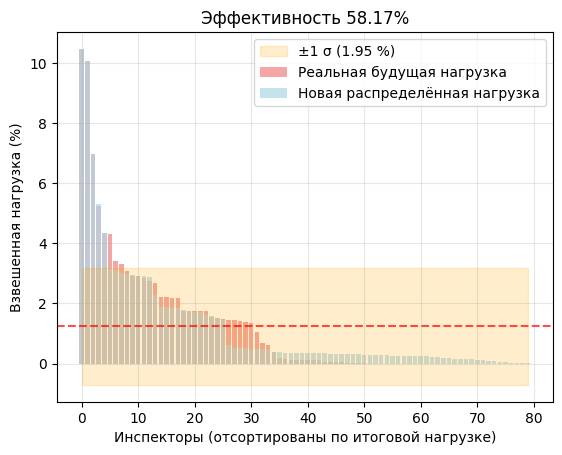

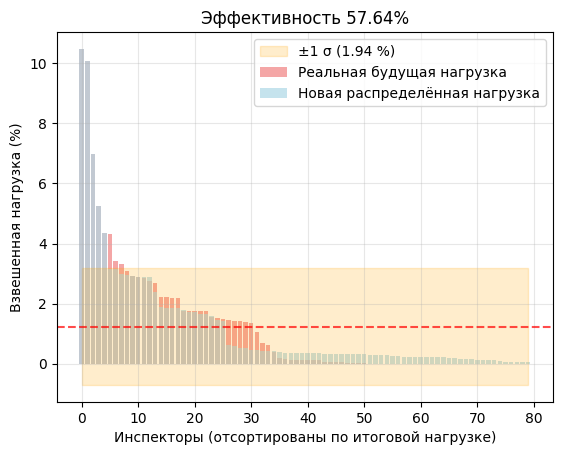

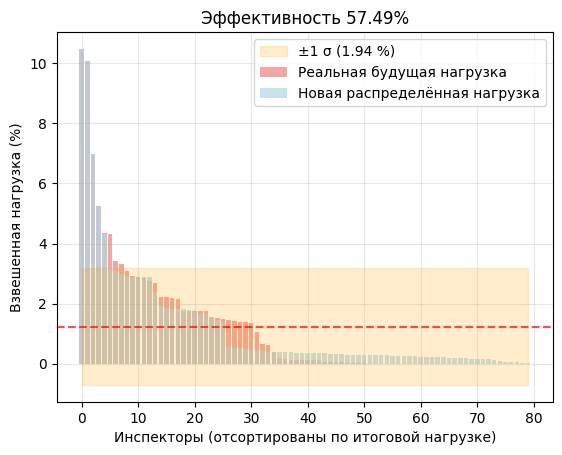

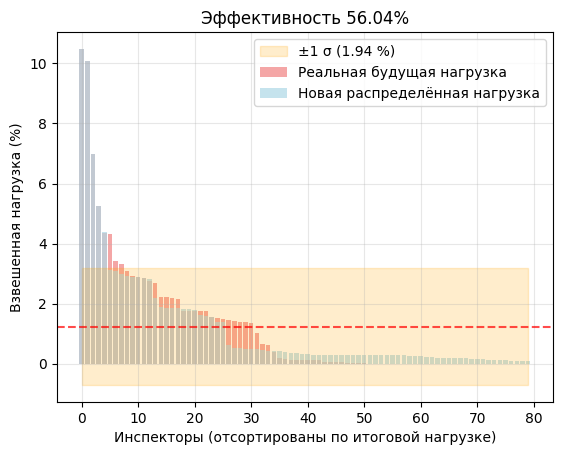

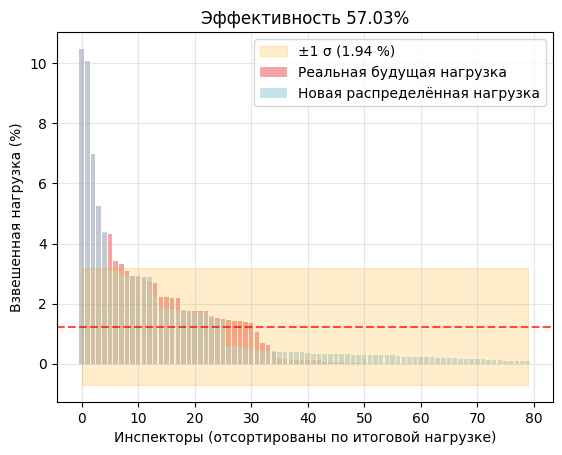

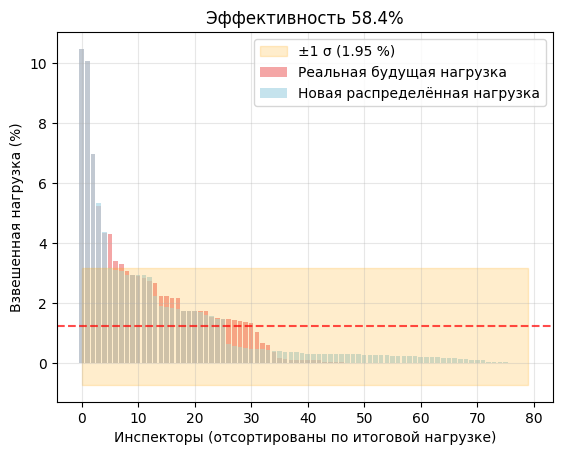

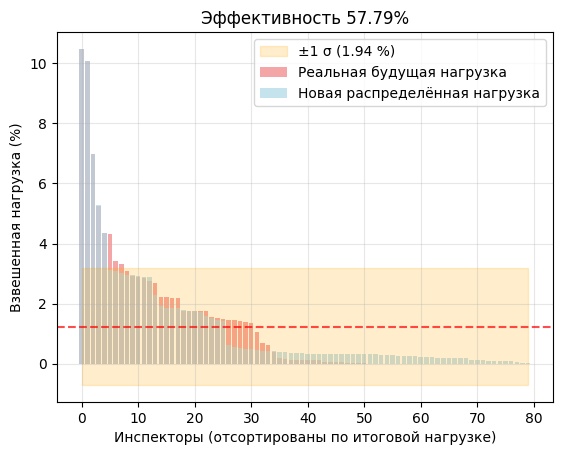

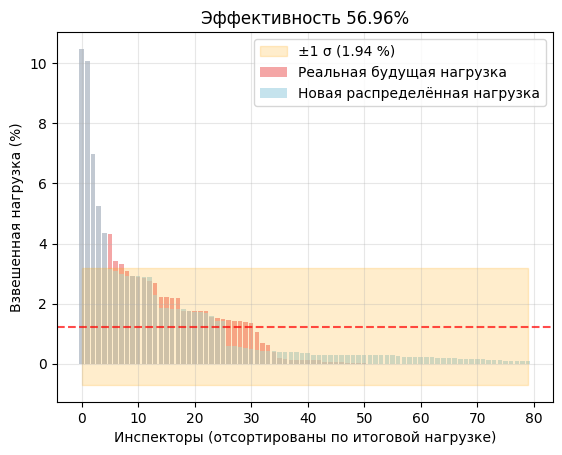

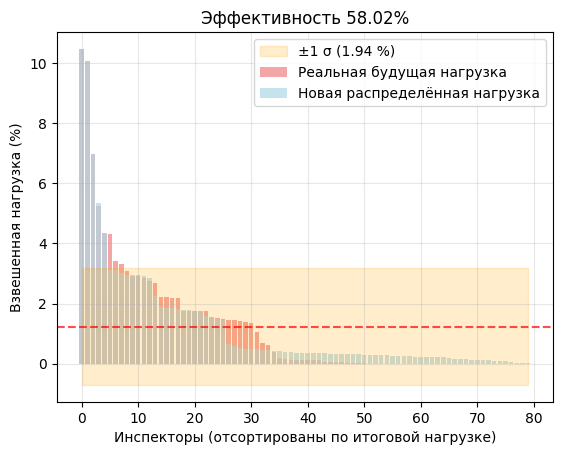

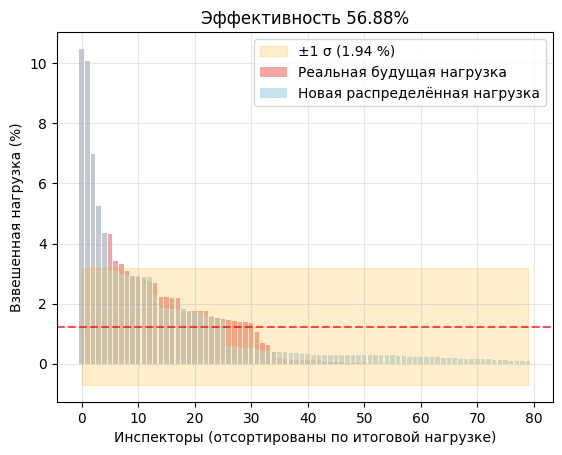

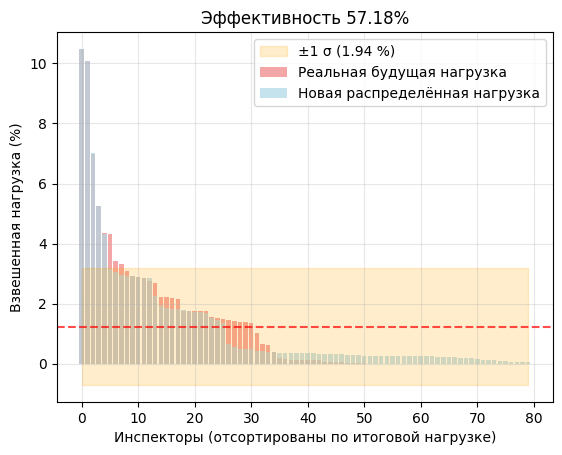

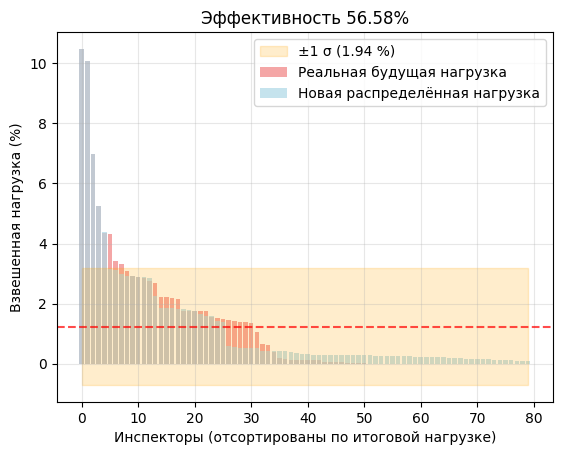

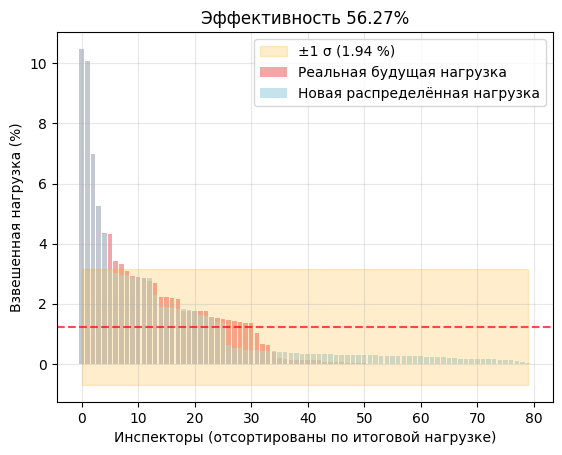

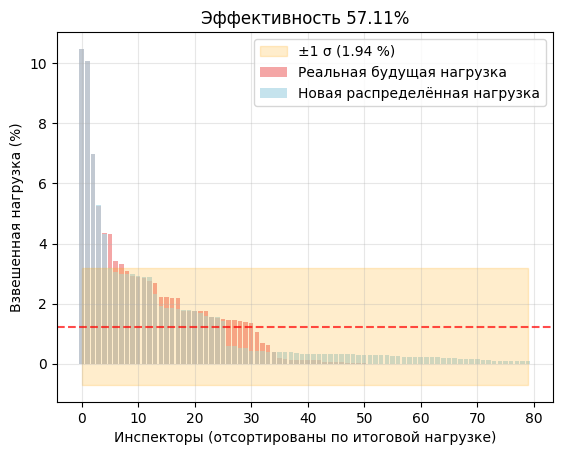

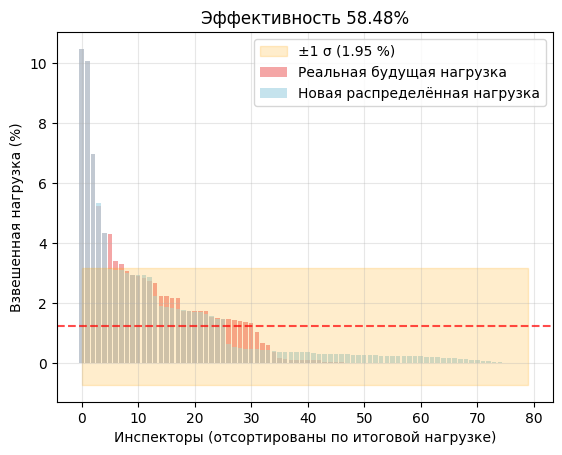

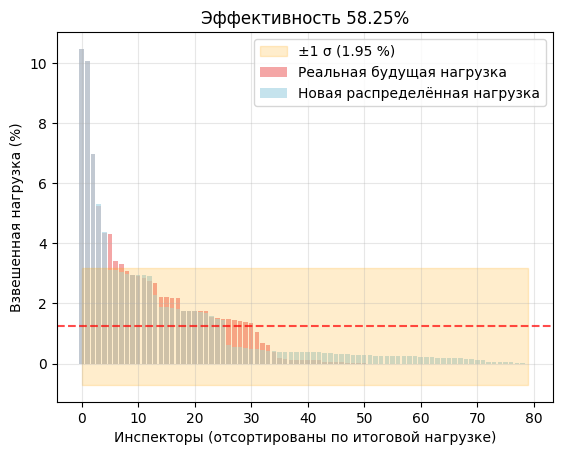

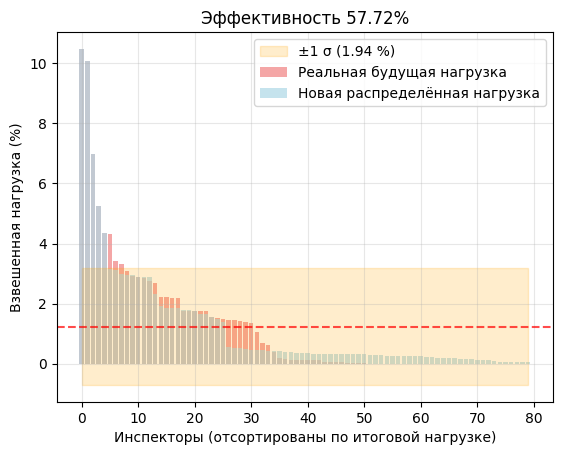

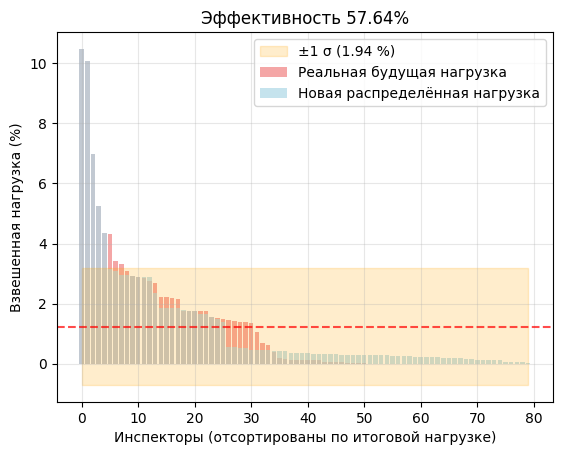

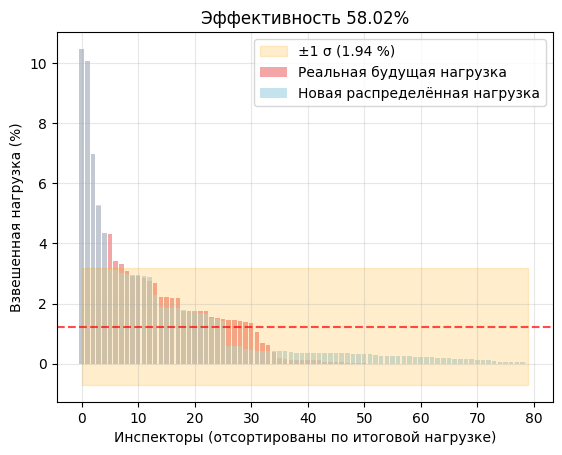

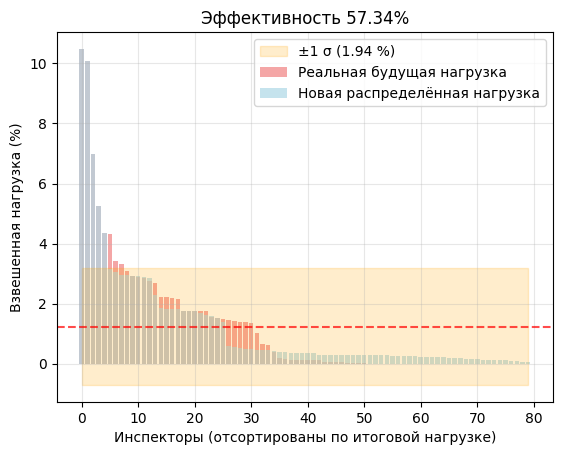

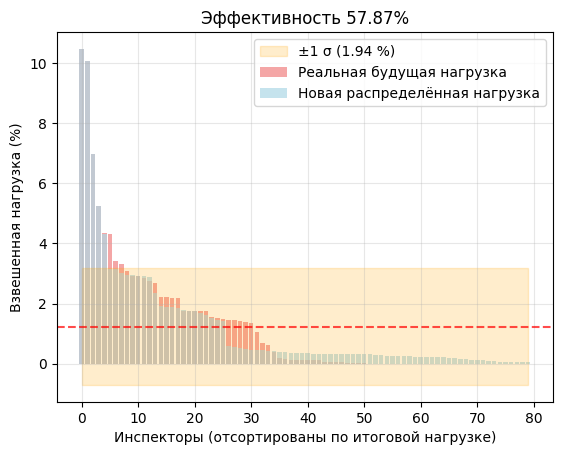

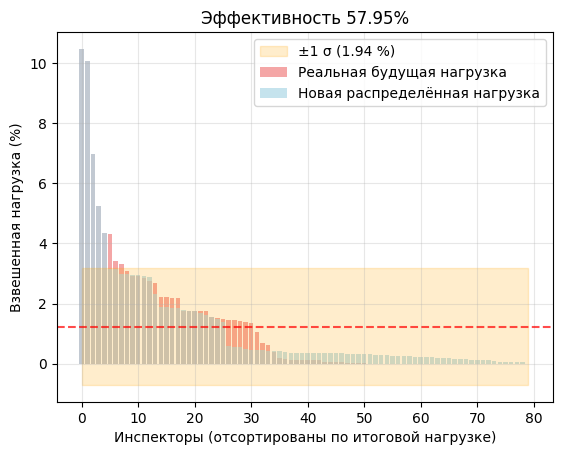

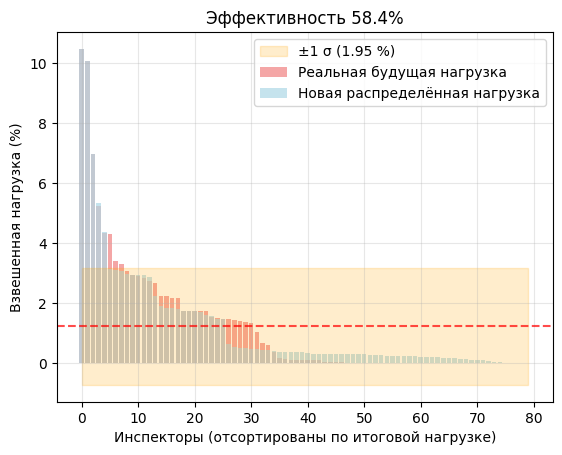

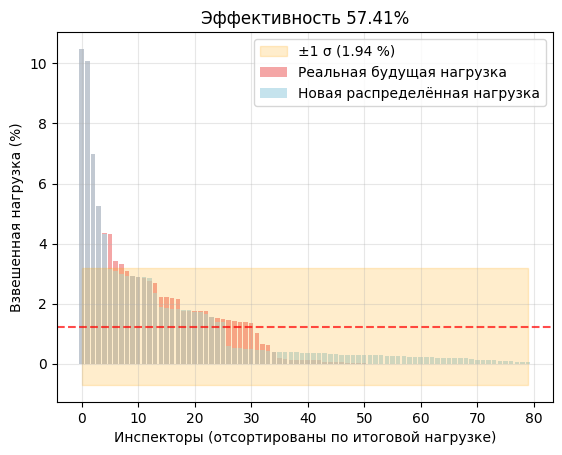

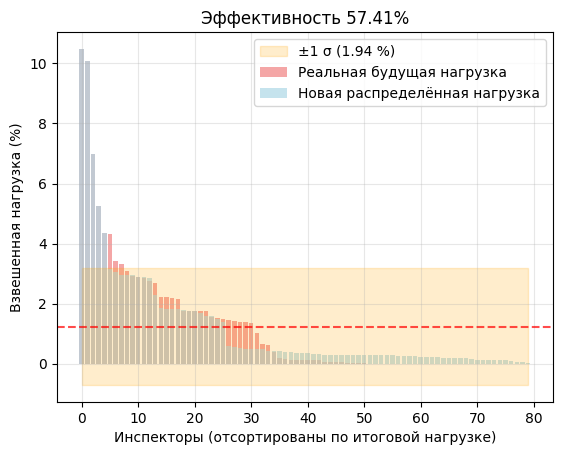

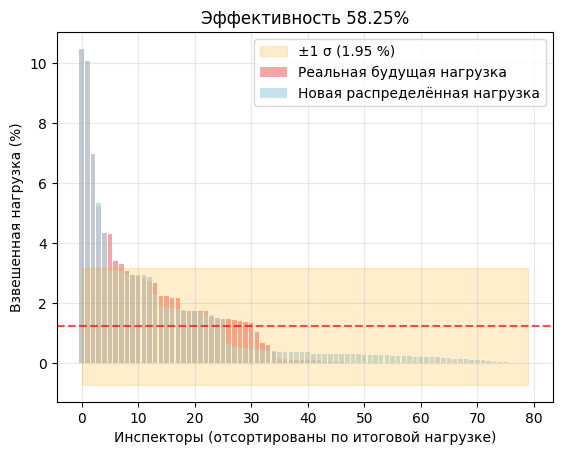

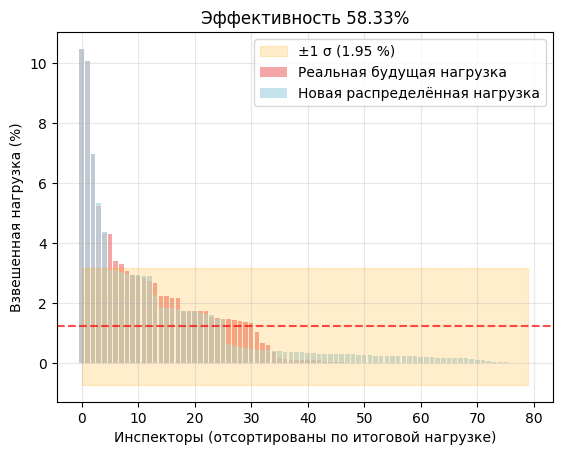

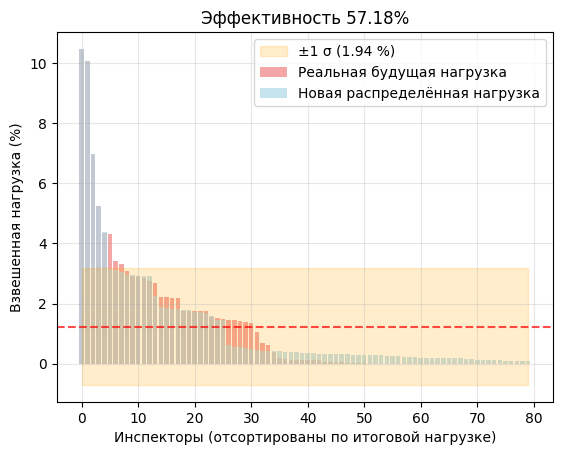

In [34]:
index = [i for i in range(len(no_inspectors_df))]
for pareto_ind in uniq_pareto:
    load, eff = evaluation(pareto_ind, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
    sorted_load = np.sort(load)[::-1]
    current_mean = load.mean()
    std = load.std()    
    plt.bar(x=index, height=sorted_future_load, width=0.8, label='Реальная будущая нагрузка', color='lightcoral',  alpha = 0.7)
    # plt.bar(x=index, height=sorted_current_load, width=0.8, label='Текущая распределённая нагрузка', color='lightcoral',  alpha = 0.7)
    plt.bar(x=index, height=sorted_load, width=0.8, label='Новая распределённая нагрузка', color='lightblue',  alpha = 0.7)
    plt.axhline(y=current_mean, color='red', linestyle='--', alpha=0.7)
    plt.fill_between(x=index, y1=current_mean - std, y2=current_mean + std,
                 color="orange", alpha=0.2, label=f"±1 σ ({std:.2f} %)")
    plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
    plt.ylabel('Взвешенная нагрузка (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Эффективность {round(eff, 2)}%')
    plt.show()
# improvement = ((current_mean - final_mean) / current_mean * 100) if current_mean > 0 else 0
# ax1.axhline(y=final_mean, color='blue', linestyle='--', alpha=0.7)

In [35]:
def huper_volum(pareto: list, r: tuple = (100,0)):
    point_sample = sorted(pareto)
    V = abs(point_sample[0][0] - r[0])*abs(point_sample[0][1] - r[1])
    for i in range(len(point_sample)-1):
        V += abs(point_sample[i][0] - point_sample[i+1][0])*abs(point_sample[i][1] - point_sample[i+1][1])
    return V

In [36]:
def __CalculateEuclideanDistance(point1, point2):
    sum_of_square = 0
    for i in range(len(point1)):
        sum_of_square += (point1[i] - point2[i]) ** 2
    return math.sqrt(sum_of_square)

In [37]:
def GD(pareto_set: list, targets: list, degree: int = 2) -> float:
    pareto_set.sort()
    targets.sort()
    idx_target = 0
    distance = 0
    for point in pareto_set:
        cur_dist = __CalculateEuclideanDistance(point, targets[idx_target])
        if (idx_target < len(targets) - 1):
            next_dist = __CalculateEuclideanDistance(point, targets[idx_target + 1])
            while (next_dist <= cur_dist) and (idx_target < len(targets) - 2):                
                idx_target += 1
                cur_dist = next_dist
                next_dist = __CalculateEuclideanDistance(point, targets[idx_target + 1])
        distance += cur_dist ** degree
    distance = (distance / len(pareto_set)) ** (1 / degree) 
    return distance

In [40]:
def max_deviation(load: np.array):    
    return load.max() - load.mean()

In [41]:
huper_volum([ind.fitness.values for ind in uniq_pareto], r = (100, 0))

np.float64(5316.676968887295)

In [42]:
GD([ind.fitness.values for ind in uniq_pareto], [(0, 100)])

41.93941623843664

In [43]:
max_deviation(load)

np.float64(9.246724890829693)

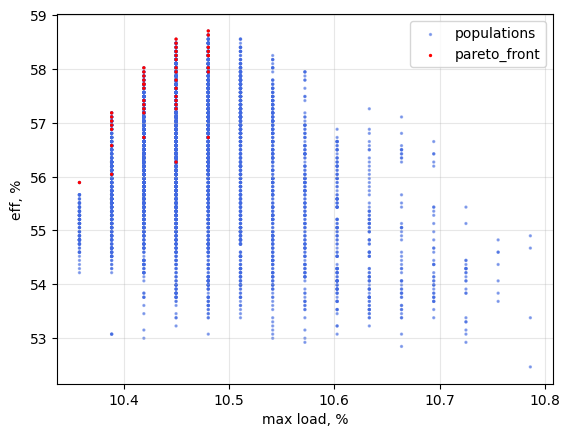

In [44]:
# Получаем все сохраненные популяции
all_generations = hall_of_fame.items

# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1], value[2]] for value in populations]
populations = [*zip(*populations)]

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1], value[2]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]

plt.scatter(populations[0], populations[1], populations[2], c='royalblue', alpha=0.5)
plt.scatter(pareto_front[0], pareto_front[1], pareto_front[2], c='red')
plt.legend(['populations', 'pareto_front'])
plt.xlabel('max load, %')
plt.ylabel('eff, %')
plt.grid(True, alpha=0.3)

In [45]:
# GD = 0
# for i in range(len(pareto_front[0]) - 1):
#     GD += (pareto_front[0][i] - pareto_front[0][i+1])**2 + (pareto_front[1][i] - pareto_front[1][i+1])**2
# GD = GD**0.5
# GD

In [46]:
def start_exp(mut, path):
    random.seed(42)
    np.random.seed(42)
    
    current_no_inspectors_df, current_no_df = filter_by_no(no_code, inwork_tasks_df)
    current_no_df = current_no_df.merge(current_no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
    current_individ = current_no_df['Inspector index'].to_list()

    no_inspectors_df, no_df = filter_by_no(no_code)
    no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)
    task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
    hall_of_fame, uniq_pareto = Multi_optimization(no_code, p_mutation=mut, p_crossing=1-mut)
    all_generations = hall_of_fame.items
    # all_generations.
    populations = [ind.fitness.values for ind in all_generations]
    populations = [[value[0], value[1]] for value in populations]
    populations = [*zip(*populations)]

    pareto_front = [ind.fitness.values for ind in uniq_pareto]
    pareto_front = [[value[0], value[1]] for value in pareto_front]
    pareto_front = [*zip(*pareto_front)]

    plt.scatter(populations[0], populations[1], c='royalblue', alpha=0.5)
    plt.scatter(pareto_front[0], pareto_front[1], c='red')
    plt.legend(['populations', 'pareto_front'])
    plt.xlabel('max load, %')
    plt.ylabel('eff, %')
    plt.grid(True, alpha=0.3)
    plt.savefig(path + '\pareto_front.png')
    plt.close()
    
    index = [i for i in range(len(no_inspectors_df))]
    for i, pareto_ind in enumerate(uniq_pareto):
        load, eff = evaluation(pareto_ind, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
        sorted_load = np.sort(load)[::-1]
        current_mean = load.mean()
        std = load.std()    
        # plt.bar(x=index, height=sorted_future_load, width=0.8, label='Реальная будущая нагрузка', color='lightcoral',  alpha = 0.7)
        plt.bar(x=index, height=sorted_current_load, width=0.8, label='Текущая распределённая нагрузка', color='lightcoral',  alpha = 0.7)
        plt.bar(x=index, height=sorted_load, width=0.8, label='Новая распределённая нагрузка', color='lightblue',  alpha = 0.7)
        plt.axhline(y=current_mean, color='red', linestyle='--', alpha=0.7)
        plt.fill_between(x=index, y1=current_mean - std, y2=current_mean + std,
                    color="orange", alpha=0.2, label=f"±1 σ ({std:.2f} %)")
        plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
        plt.ylabel('Взвешенная нагрузка (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.title(f'Эффективность {round(eff, 2)}%')
        plt.savefig(path + f'\load_distribution_{i}.png')
        plt.close()
    front = [ind.fitness.values for ind in uniq_pareto]
    
    hv = huper_volum(front, r = (100, 0))
        
    gd_metrick = GD(front, [(0, 100)])
    
    with open(path + '\out.txt', 'w') as output:
        output.write(f"Len of Pareto set: {len(uniq_pareto)},\n\
            Huper volum: {hv},\nGenerational distance {gd_metrick},\n\
                Resulrs: {[ind.fitness.values for ind in uniq_pareto]}")
    

In [ ]:
# start_exp(0.2, 'D:\Python\РЗС\exp\exp_1_1')

C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

   	      	                 fit1                 	                 fit2                 
   	      	--------------------------------------	--------------------------------------
gen	nevals	avg    	gen	max    	min    	nevals	avg    	gen	max    	min    	nevals
0  	200   	10.6575	0  	10.8472	10.5109	200   	54.0986	0  	55.4338	52.4658	200   
1  	100   	10.6222	1  	10.8167	10.4803	100   	54.6644	1  	55.586 	53.2268	100   
2  	100   	10.6069	2  	10.9084	10.4803	100   	54.9224	2  	56.1948	53.2268	100   
3  	100   	10.599 	3  	10.7861	10.4803	100   	55.1682	3  	56.1948	54.0639	100   
4  	100   	10.5812	4  	10.7861	10.4803	100   	55.2572	4  	56.1948	54.2922	100   
5  	100   	10.5632	5  	10.7249	10.4803	100   	55.3691	5  	56.4231	54.2922	100   
6  	100   	10.5571	6  	10.7249	10.4803	100   	55.497 	6  	56.4231	54.5205	100   
7  	100   	10.5552	7  	10.6944	10.4803	100   	55.6705	7  	56.5753	54.9011	100   
8  	100   	10.5439	8  	10.6944	10.4803	100   	55.86  	8  	56.8037	55.2055	100   
9  	100   	1

In [48]:
# import plotly.graph_objects as go
# from ipywidgets import Output
# import ipywidgets as widgets

# output_area = Output()

# fig = go.FigureWidget()
# # fig.update_yaxes(range=[0, 100])
# # fig.update_xaxes(range=[0, 10])
# fig.add_trace(go.Scatter(x=populations[0], y=populations[1], mode='markers',  marker_color="royalblue", name='populations', customdata=populations[2]))
# fig.add_trace(go.Scatter(x=pareto_front[0], y=pareto_front[1], mode='markers',  marker_color="Red", name='pareto front', customdata=pareto_front[2]))
# fig.update_layout(title="Distribution of individuals",
#                 xaxis_title='max load, %',
#                 yaxis_title='eff, %',
#                 margin=dict(l=0, r=0, t=30, b=0))
# fig.update_traces(hoverinfo="all", hovertemplate="Макс. нагрузка: %{x}<br>Эффективность: %{y}")

# # Функция обработки клика
# def handle_click(trace, points, selector):
#     if points.point_inds:
#         index = points.point_inds[0]
#         with output_area:
#             output_area.clear_output()
#             print(f"Тип данных: {trace.name}")
#             print(f"Индекс точки: {index}")
#             print("Список параметров:")
#             # Предполагаем, что customdata[index] - это список параметров
#             for i, param in enumerate(trace.customdata[index]):
#                 print(f"Параметр {i+1}: {param}")

# # Регистрируем обработчики
# fig.data[0].on_click(handle_click)
# fig.data[1].on_click(handle_click)

# # Отображаем график и область вывода
# display(widgets.VBox([fig, output_area]))

In [49]:
# future_individ = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб', 'ИНН НП', 'Инспектор, сменивший статус']].copy()
# future_individ = future_individ.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='Инспектор, сменивший статус', right_on='Инспектор, сменивший статус')
# future_individ = future_individ['Inspector index'].to_list()
# future_load, future_eff = evaluation(future_individ, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)

In [50]:
# individ = uniq_pareto[0] + current_individ
# result_df = pd.concat([no_df, current_no_df])[['Статус РСЗ', 'Тип']]
result_df = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
result_df['New Inspector index'] = uniq_pareto[0]
result_df.reset_index(inplace=True)
result_df['Статус РСЗ'] = result_df['Статус РСЗ'].replace('Новое', 'В работе')
result_df = result_df.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='New Inspector index', right_on='Inspector index')
result_df.rename(columns={'Инспектор, сменивший статус_x': 'Назначеный инспектор', 'Инспектор, сменивший статус_y': 'Предлагаемый к назначению инспектор'}, inplace=True)
result_df.drop(columns='Inspector index', inplace=True)
# pd.set_option('display.max_rows', None)
result_df

,№ схемы/риска,Статус РСЗ,Тип,"Потенциальный ущерб, руб",ИНН НП,Назначеный инспектор,New Inspector index,Предлагаемый к назначению инспектор
0,9420904,В работе,RISK_SHORT,11651.3250,413-adf-nuwi-ybqtd,47193-furq-gxfzjj-jdtuffag,0,11111-iyri-uwwjst-chzuradt
1,9420908,В работе,RISK_SHORT,15378.4530,118-rbr-gatp-mkjaj,51991-qqjk-njapnh-ncogwkwn,67,82534-eopm-huaobw-foiosglr
2,9421022,В работе,RISK_SHORT,31799.7792,482-qbx-agag-xwxwo,83625-jaer-sxgcqc-wfgnzlud,48,58765-jqrh-gzymls-pynrkyag
3,9421068,В работе,RISK_SHORT,327190.5696,117-zwj-qwtn-pagcx,80453-ypvh-csnihx-pyhdiaxk,15,31562-isla-tjkrsf-kcziuhoz
4,9421380,В работе,RISK_SHORT,37005.2001,252-had-pstw-mlxcw,83625-jaer-sxgcqc-wfgnzlud,8,25803-fawg-dtxvcf-ixctthau
...,...,...,...,...,...,...,...,...
456,9463114,В работе,RISK_SHORT,49837.1481,435-yaw-jdxd-ouvmz,72453-jqlc-bljers-ylgrdpkk,51,69905-xcvi-lmlljp-iqttesrb
457,9463119,В работе,RISK_SHORT,7324.4616,564-iqi-jxea-efvwp,72453-jqlc-bljers-ylgrdpkk,18,35892-enzt-fekfiq-hxexixxy
458,9463233,В работе,RISK_SHORT,41929.5996,256-tbe-bgyd-jqswc,30147-xttf-czzgka-loxcmivw,37,50813-poix-olclan-fszspndj
459,9463285,В работе,RISK_SHORT,49029.2514,740-jhq-uyau-rsrkq,30147-xttf-czzgka-loxcmivw,45,56050-aqkr-hfyuxw-gpdzicqq


In [51]:
import numpy as np
import random
from typing import List, Tuple, Callable, Dict, Any

In [52]:
class Solution:
    def __init__(self, params: List[int], scores: Tuple[float, ...]):
        self.params = params
        self.scores = scores

    def __eq__(self, other):
        return tuple(self.params) == tuple(other.params)

    def __hash__(self):
        return hash(tuple(self.params))

    def dominates(self, other, weights) -> bool:
        weights = tuple(w if w != 0 else -1 for w in weights)
        better_or_eq = all(a*c >= b*c for a, b, c in zip(self.scores, other.scores, weights))
        better = any(a*c > b*c for a, b, c in zip(self.scores, other.scores, weights))
        return better_or_eq and better

class ParetoArchive:
    def __init__(self):
        self.archive = set()

    def update(self, weights, candidates: List[Solution]):
        for cand in candidates:
            to_remove = set()
            dominated = False
            for arch in self.archive:
                if cand.dominates(arch, weights):
                    to_remove.add(arch)
                elif arch.dominates(cand, weights):
                    dominated = True
                    break
            if not dominated:
                self.archive.difference_update(to_remove)
                self.archive.add(cand)

    def get(self) -> List[Solution]:
        return list(self.archive)

class AntColonyOptimizer:
    def __init__(
        self,
        func: Callable[[List[int]], Tuple[float, ...]],
        param_ranges: List[Tuple[int, int]],        
        weights: Tuple[float, ...],
        n_ants: int = 30,
        n_iter: int = 50,
        alpha: float = 1.0,
        beta: float = 2.0,
        evaporation: float = 0.5
    ):
        self.func = func
        self.dim = len(param_ranges)
        self.ranges = param_ranges
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.alpha = alpha
        self.beta = beta
        self.evaporation = evaporation
        self.pheromones = [np.ones(r[1] - r[0] + 1) for r in param_ranges]
        self.solutions = []
        self.weights = weights

    def sample_ant(self) -> List[int]:
        params = []
        for d in range(self.dim):
            tau = self.pheromones[d]
            possible_vals = list(range(self.ranges[d][0], self.ranges[d][1] + 1))
            eta = np.ones_like(tau)
            probs = (tau ** self.alpha) * (eta ** self.beta)
            probs = probs / probs.sum()
            val = random.choices(possible_vals, weights=probs)[0]
            params.append(val)
        return params

    def update_pheromones(self, pareto_solutions: List[Solution]):
        for d in range(self.dim):
            self.pheromones[d] *= (1 - self.evaporation)
        for sol in pareto_solutions:
            for d, val in enumerate(sol.params):
                self.pheromones[d][val - self.ranges[d][0]] += 1

    def run(self) -> Dict[str, Any]:
        archive = ParetoArchive()
        for it in range(self.n_iter):
            candidates = []
            for ant in range(self.n_ants):
                params = self.sample_ant()
                scores = self.func(params)
                sol = Solution(params, scores)
                candidates.append(sol)
                self.solutions.append(sol)
            archive.update(weights=self.weights, candidates=candidates)
            self.update_pheromones(archive.get())
        return {
            "explored": self.solutions, #[(sol.params, sol.scores) for sol in self.solutions],
            "pareto_front": archive.get() #[(sol.params, sol.scores) for sol in archive.get()]
        }

In [11]:
M = 3
N = 7
param_ranges = [(0, M-1)] * N
print(param_ranges)
pheromones = [np.ones(r[1] - r[0] + 1) for r in param_ranges]
print(pheromones)
for d in range(len(param_ranges)):
    tau = pheromones[d]
    possible_vals = list(range(param_ranges[d][0], param_ranges[d][1] + 1))
    eta = np.ones_like(tau)
    probs = (tau ** 1) * (eta ** 2)
    probs = probs / probs.sum()
    val = random.choices(possible_vals, weights=probs)[0]
    print(possible_vals)
    print(val)

[(0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2)]
[array([1., 1., 1.]), array([1., 1., 1.]), array([1., 1., 1.]), array([1., 1., 1.]), array([1., 1., 1.]), array([1., 1., 1.]), array([1., 1., 1.])]
[0, 1, 2]
1
[0, 1, 2]
1
[0, 1, 2]
0
[0, 1, 2]
1
[0, 1, 2]
2
[0, 1, 2]
0
[0, 1, 2]
2


In [53]:
def test_func(params: List[int]) -> Tuple[float, float]:
    # Минимизируем сумму квадратов (критерий 1) и сумму отклонений от [1,2,3,4] (критерий 2)
    crit1 = sum(x ** 2 for x in params)
    crit2 = sum((x - target) ** 2 for x, target in zip(params, [1, 2, 3, 4]))
    return (crit1, crit2)

In [54]:
no_inspectors_df, no_df = filter_by_no(3700)
no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)
task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
in_work_indiv = in_work_no_df.merge(no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
in_work_indiv = in_work_indiv['Inspector index'].to_list()

C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
C:\Users\zincc\AppData\Local\Temp\ipykernel_22556\3179637002.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [55]:
param_ranges = [(0, M-1)] * N
eval = partial(evaluation, den_TNO=den_TNO, task_cat=task_cat, task_prob=task_prob, M=M, current_individ=in_work_indiv)

optimizer = AntColonyOptimizer(
    func=eval,
    param_ranges=param_ranges,
    n_ants=60,
    n_iter=100,
    weights=(-1, 1)
)
result = optimizer.run()

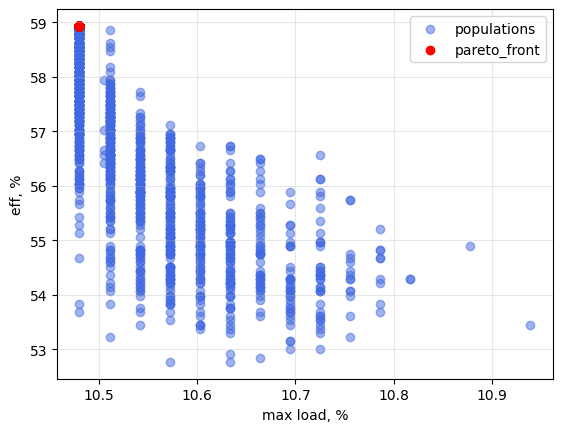

In [56]:
prto = [sol.scores for sol in result["pareto_front"]]
prto = [*zip(*prto)]

# all_generations.
populations = [sol.scores for sol in result["explored"]]
populations = [*zip(*populations)]

plt.scatter(populations[0], populations[1], c='royalblue', alpha=0.5)
plt.scatter(prto[0], prto[1], c='red')
plt.legend(['populations', 'pareto_front'])
plt.xlabel('max load, %')
plt.ylabel('eff, %')
plt.grid(True, alpha=0.3)

In [57]:
GD([ind.fitness.values for ind in uniq_pareto], [(0, 100)])

41.93941623843664

In [58]:
GD([*zip(*prto)], [(0, 100)])

42.38170389259312

In [59]:
huper_volum([ind.fitness.values for ind in uniq_pareto], r = (100, 0))

np.float64(5316.676968887295)

In [60]:
huper_volum([*zip(*prto)], r = (100, 0))

np.float64(5275.800416076781)